# <span style="color: rgba(230, 0, 126, 1);"> DESPINA </span> #

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_rows', 20)

In [3]:
# cargar los dos dfs
# df del INE con edades de 18 a 95 años como en df de la banca, y entre 2025 y 2035
df_ine = pd.read_csv(r"C:\Users\tinke\Downloads\36643.csv", encoding='latin-1', sep=';')
df_banca = pd.read_csv(r"C:\Users\tinke\Desktop\simulador empresarial\101125_dataset.csv", sep=';')

#### Limpieza y tranformación df_ine

In [4]:
# normalizar la columna Edad extrayendo solo los números del str y convertirla en integro
df_ine['Edad']=df_ine['Edad'].str.extract(r'(\d+)').astype(int)

In [5]:
# normalizar la columna Total, eliminando el punto de los miles y cambiando el coma de los decimales a punto, convertir la columna en float
df_ine['Total']=(df_ine['Total'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float).
                 round(0).astype(int))          # redondear a 0 decimales y cambiar tipo a integro

In [6]:
# categorizar edades según Encuesta Competencias Financieras, Banco de España
# definir los límites de los rangos etarios

bins = [18, 34, 44, 54, 64, 79, 95]

labels = ['18-34' , '35-44', '45-54', '55-64', '65-79', '>79']

df_ine['rango_edad'] = pd.cut(df_ine.Edad, bins = bins, labels=labels, include_lowest= True)

In [7]:
def generación(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - 'Generation Z y Millenials' : si la edad es menor a 35
       - 'Generation X' : si la edad es menor a 55
       - 'Baby Boomers' : si la edad es mayor o igual a 55
       '''

    if x < 35:
        return 'Generation Z y Millenials'
    elif x < 55:
        return 'Generation X'
    elif x >= 55:
        return 'Baby Boomers'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df_ine['generaciones'] = df_ine['Edad'].apply(generación)

# Verificacion de distribución
(df_ine['generaciones'].value_counts()).round(2)

generaciones
Baby Boomers                 451
Generation X                 220
Generation Z y Millenials    187
Name: count, dtype: int64

In [8]:
df_ine

,Sexo,Edad,Periodo,Total,rango_edad,generaciones
0,Total,18,2035,516698,18-34,Generation Z y Millenials
1,Total,18,2034,525687,18-34,Generation Z y Millenials
2,Total,18,2033,531479,18-34,Generation Z y Millenials
3,Total,18,2032,525167,18-34,Generation Z y Millenials
4,Total,18,2031,547783,18-34,Generation Z y Millenials
...,...,...,...,...,...,...
853,Total,95,2029,58449,>79,Baby Boomers
854,Total,95,2028,57259,>79,Baby Boomers
855,Total,95,2027,52969,>79,Baby Boomers
856,Total,95,2026,52149,>79,Baby Boomers


In [9]:
# extraer el df con transformaciones to csv para Power BI
df_ine.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\df_ine.csv",sep=";",index=False)

#### Tranformación df_banca

In [10]:
def age_groups(x):

    '''Clasifica el valor de edad numérico dentro de un rango
       ----------
       Parámetro
       x : float - Edad de una persona.
       -------
       Retorna        
       Grupo de edad correspondiente según los siguientes rangos:
       - '18-34' : si la edad es menor a 35
       - '35-44' : si la edad es menor a 45
       - '45-54' : si la edad es menor a 55
       - '55-64' : si la edad es menor a 65
       - '65-79' : si la edad es menor a 80
       - '>79' : en el resto de los casos'''

    if x < 35:
        return '18-34'
    elif x < 45:
        return '35-44'
    elif x < 55:
        return '45-54'
    elif x < 65:
        return '55-64'
    elif x < 80:
        return '65-79'
    else:
        return '>79'
    
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df_banca['age_group'] = df_banca['age'].apply(age_groups)

# Verificacion de distribución
(df_banca['age_group'].value_counts()).round(2)

age_group
18-34    9096
35-44    7861
45-54    5177
55-64    3048
65-79     821
>79       173
Name: count, dtype: int64

In [11]:
# Crear una nueva columna 'age_group' aplicando la función age_groups a la columna 'age'
df_banca['age_clusters'] = df_banca['age'].apply(generación)

# Verificacion de distribución
(df_banca['age_clusters'].value_counts()).round(2)

age_clusters
Generation X                 13038
Generation Z y Millenials     9096
Baby Boomers                  4042
Name: count, dtype: int64

In [12]:
def simplify_job(job):

    '''     Clasifica cada valor dentro de una categoría nueva de empleos
       ----------
       Parámetro
       x : object - Ocupación de cada cliente.
       -------
       Retorna        
       Etiqueta de nueva catgorización de los empleos:
       - 'cuenta ajena' : si los valores son 'management', 'technician', 'administrative', 'services' y 'blue-collar'
       - 'cuenta propia' : si los valores son 'self-employed', 'entrepreneur'
       - 'jubilación' : si 'retired'
       - 'otros inactivos' : si los valores son 'student', 'housemaid'
       - 'desempleo' : si el valor es 'unemployed'
       '''
      
    job = str(job).lower().strip()
    if job in ['management', 'technician', 'administrative', 'services', 'blue-collar']:
        return 'cuenta ajena'
    elif job in ['unemployed']:
        return 'desempleo'
    elif job in ['self-employed', 'entrepreneur']:
         return 'cuenta propia'
    elif job in ['retired']:
        return 'jubilación'
    else:
        return 'otros inactivos'

    
# Aplicar la función y crear una columna nueva job_cat
df_banca['job_cat'] = df_banca['job'].apply(simplify_job)

# Verificacion de distribución
(df_banca['job_cat'].value_counts(normalize=True)).round(2)

job_cat
cuenta ajena       0.77
jubilación         0.07
cuenta propia      0.07
otros inactivos    0.06
desempleo          0.03
Name: proportion, dtype: float64

In [13]:
# Education

def simplify_edu(edu):

    '''     Cambia el valor de la columna 'education' renombrándo cada uno
       ----------
       Parámetro
       x : object - nivel educativo.
       -------
       Retorna        
       Etiqueta nueva de los niveles educativos:
       - 'Primaria' : si el valor es 'primary'
       - 'Secundaria' : si el valor es 'secondary'
       - 'Universitaria'  : si el valor es 'tertiary'
    '''
    
    edu = str(edu).lower()
    if 'primary' in edu:
        return 'Primaria'
    elif 'secondary' in edu:
        return 'Secundaria'
    else:
        'tertiary' in edu or 'university' in edu
        return 'Universitaria'

df_banca['education_level'] = df_banca['education'].apply(simplify_edu)

# Verificacion de la distribución
(df_banca['education_level'].value_counts(normalize=True)).round(2)

education_level
Secundaria       0.52
Universitaria    0.34
Primaria         0.14
Name: proportion, dtype: float64

### clusters

In [14]:
# Seleccionar las variables para el clustering
demo_vars = ['age_clusters', 'job_cat', 'education_level', 'marital']
df_cat = df_banca[demo_vars].copy()

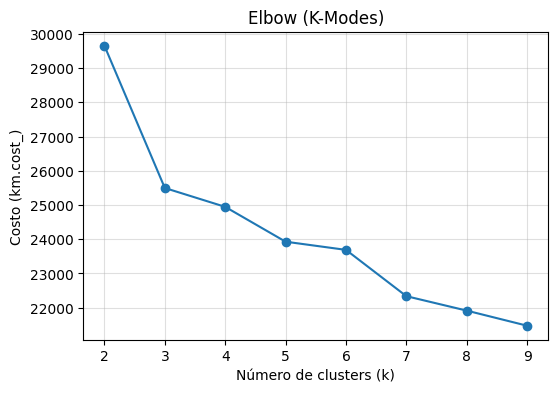

In [15]:
# Metodo de codo (Elbow) para KModes para encontar el número óptimo de clusters
K = range(2, 10)
cost = []

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, verbose=0, random_state=42) # se pueden usar init= Cao o Huang
    km.fit_predict(df_cat)
    cost.append(km.cost_)

plt.figure(figsize=(6,4))
plt.plot(K, cost, marker='o')
plt.title('Elbow (K-Modes)')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Costo (km.cost_)')
plt.grid(alpha=0.4)
plt.show()


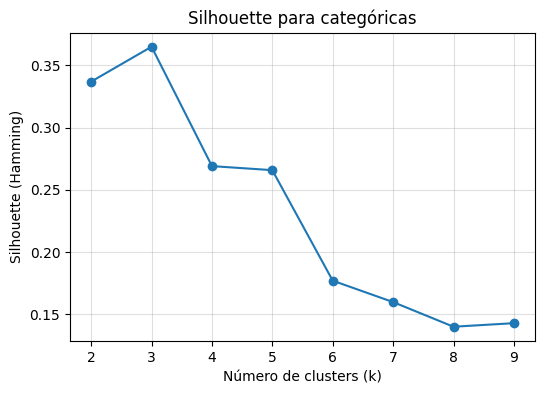

In [16]:
# Codificar variables categóricas como números para calcular silhouette (métrica Hamming), encontrar número óptimo de clusters
df_encoded = df_cat.copy()
for col in df_encoded.columns:
    df_encoded[col] = pd.factorize(df_encoded[col])[0]

sil_scores = []
K = range(2, 10)

for k in K:
    km = KModes(n_clusters=k, init='Cao', n_init=5, random_state=42)
    clusters = km.fit_predict(df_cat)
    score = silhouette_score(df_encoded, clusters, metric='hamming')
    sil_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(K, sil_scores, marker='o')
plt.title('Silhouette para categóricas')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette (Hamming)')
plt.grid(alpha=0.4)
plt.show()


## kmodes algoritmo

In [17]:
# Definir como número de clusters 3 
kmode = KModes(n_clusters=3, init = "Cao", n_init = 10, verbose=1, random_state=42) # se puede probar con Cao en init o Huang
clusters = kmode.fit_predict(df_cat)
clusters

# Añadir en df original la columna con los clusters generados
df_banca['Cluster'] = clusters 
df_cat['Cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 1481, cost: 25496.0


In [18]:
cluster_modes = pd.DataFrame(kmode.cluster_centroids_, columns=demo_vars)

cluster_modes.index = [f'Cluster_{i}' for i in range(len(cluster_modes))]

df_cat['Cluster'] = clusters
print(cluster_modes)

                        age_clusters       job_cat education_level  marital
Cluster_0               Generation X  cuenta ajena      Secundaria  married
Cluster_1  Generation Z y Millenials  cuenta ajena   Universitaria   single
Cluster_2               Baby Boomers    jubilación        Primaria  married


In [19]:
# extraer el df_banca transformado to csv
df_banca.to_csv(r"C:\Users\tinke\Desktop\simulador empresarial\banca_actualizado.csv",sep=";",index=False)

### EDA 

<Axes: xlabel='age_group'>

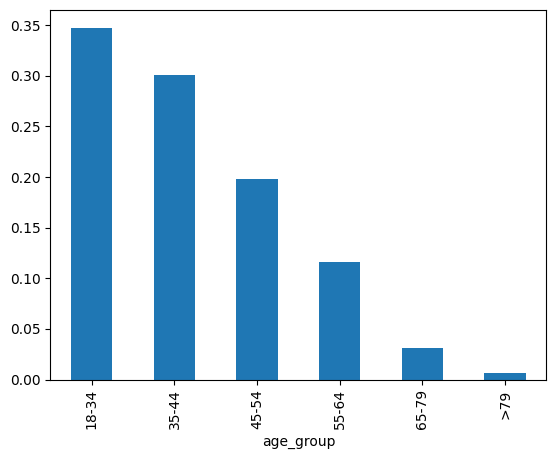

In [20]:
# revisar los rangos de edad de los clientes 
df_banca.age_group.value_counts(normalize=True).plot.bar()

<Axes: xlabel='rango_edad'>

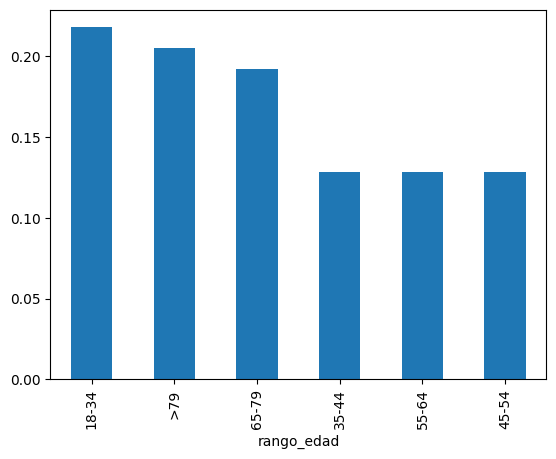

In [21]:
# rangos de edad del INE 
df_ine.rango_edad.value_counts(normalize=True).plot.bar()

In [22]:
df_banca.Cluster.value_counts()

Cluster
0    15648
1     8077
2     2451
Name: count, dtype: int64

In [23]:
pd.crosstab(df_banca.Cluster, df_banca.age_clusters)

age_clusters,Baby Boomers,Generation X,Generation Z y Millenials
Cluster,,,
0,1469,11864,2315
1,234,1117,6726
2,2339,57,55


<Axes: xlabel='Cluster'>

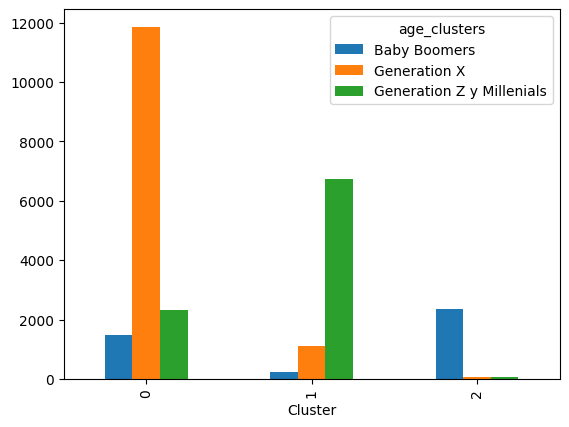

In [24]:
pd.crosstab(df_banca.Cluster, df_banca.age_clusters).plot.bar()

In [25]:
pd.crosstab(df_banca.Cluster, df_banca.age_group)

age_group,18-34,35-44,45-54,55-64,65-79,>79
Cluster,,,,,,
0,2315,6978,4886,1402,65,2
1,6726,872,245,218,16,0
2,55,11,46,1428,740,171


<Axes: xlabel='Cluster'>

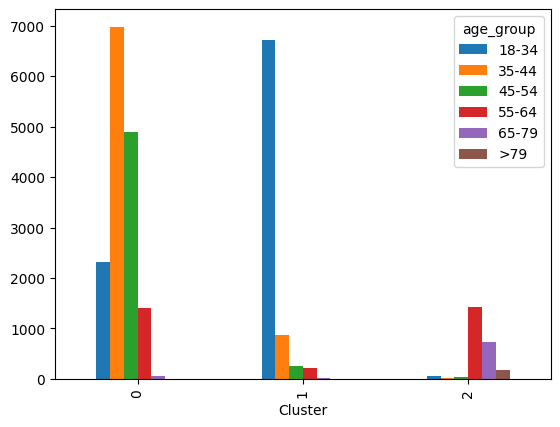

In [26]:
pd.crosstab(df_banca.Cluster, df_banca.age_group).plot.bar()

### EDA INE

In [27]:
# suma de edades por período y rango etario
a=df_ine.groupby(['Periodo', 'rango_edad'])['Total'].sum()
a.head(20)

Periodo  rango_edad
2025     18-34          9382543
         35-44          6641782
         45-54          8061628
         55-64          7025913
         65-79          7160409
         >79            2919241
2026     18-34          9645658
         35-44          6593652
         45-54          8133934
         55-64          7168323
         65-79          7347126
         >79            3000044
2027     18-34          9907936
         35-44          6568482
         45-54          8162352
         55-64          7321512
         65-79          7545349
         >79            3059827
2028     18-34         10110689
         35-44          6565153
Name: Total, dtype: int64

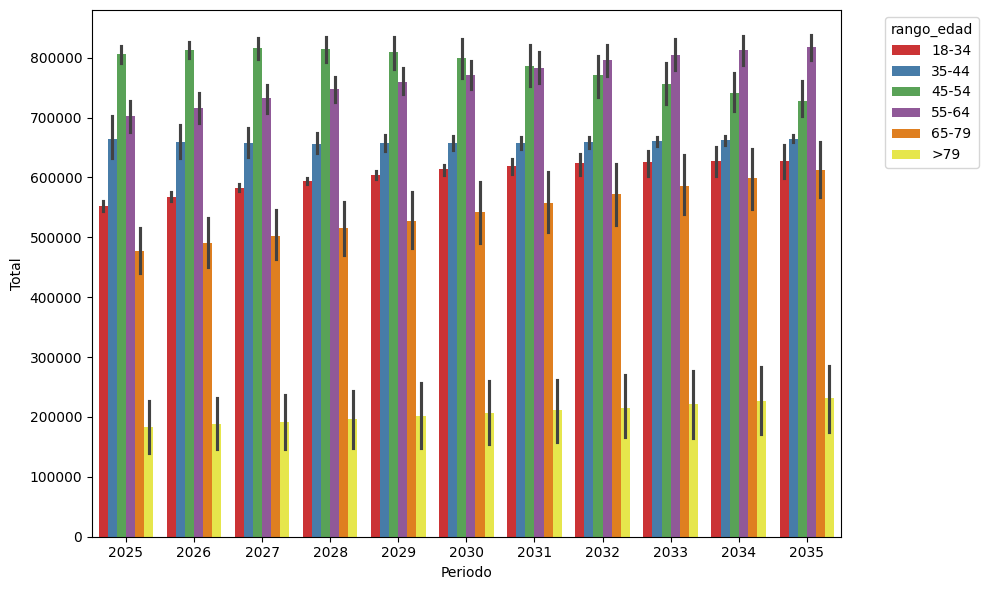

In [28]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_ine, x='Periodo', y='Total', hue='rango_edad', palette='Set1')
plt.legend(title='rango_edad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
edad_periodo_suma = df_ine.groupby(['Periodo', 'rango_edad'])['Total'].sum()

percent = round(edad_periodo_suma / edad_periodo_suma.groupby(level=0).transform('sum') * 100, 2)
percent.head(20)


Periodo  rango_edad
2025     18-34         22.78
         35-44         16.12
         45-54         19.57
         55-64         17.06
         65-79         17.38
         >79            7.09
2026     18-34         23.03
         35-44         15.74
         45-54         19.42
         55-64         17.11
         65-79         17.54
         >79            7.16
2027     18-34         23.28
         35-44         15.43
         45-54         19.18
         55-64         17.20
         65-79         17.73
         >79            7.19
2028     18-34         23.42
         35-44         15.21
Name: Total, dtype: float64

In [30]:
round(df_ine.groupby(['rango_edad'])['Total'].mean(), 2)

rango_edad
18-34    603600.44
35-44    659563.40
45-54    785743.53
55-64    767617.78
65-79    544096.72
>79      206613.91
Name: Total, dtype: float64

In [31]:
df2030= df_ine[df_ine['Periodo'].isin([2025,2026,2027,2028,2029,2030])]

In [32]:
pct2030=round(pd.crosstab(df2030.rango_edad, df2030.Periodo, values=df2030.Total, aggfunc='sum', normalize='columns')*100, 2)
pct2030

Periodo,2025,2026,2027,2028,2029,2030
rango_edad,,,,,,
18-34,22.78,23.03,23.28,23.42,23.54,23.61
35-44,16.12,15.74,15.43,15.21,15.04,14.88
45-54,19.57,19.42,19.18,18.88,18.52,18.10
55-64,17.06,17.11,17.20,17.31,17.39,17.46
65-79,17.38,17.54,17.73,17.93,18.12,18.43
>79,7.09,7.16,7.19,7.26,7.40,7.51


<Axes: xlabel='rango_edad'>

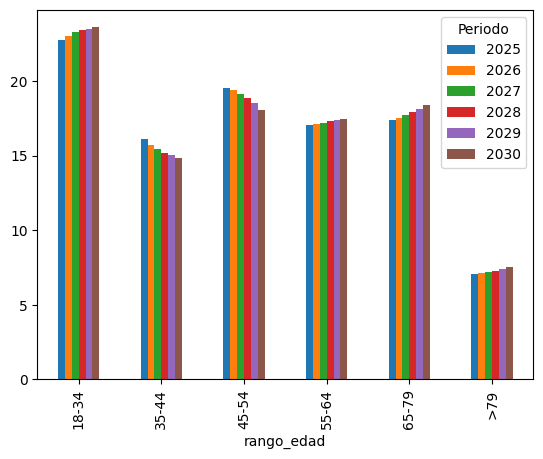

In [33]:
pct2030.plot.bar()

In [34]:
table = pd.crosstab(df2030.rango_edad, df2030.Periodo, values=df2030.Total, aggfunc='sum', normalize='columns') * 100                 

table.loc['Total'] = table.sum()

table = table.round(2)

table


Periodo,2025,2026,2027,2028,2029,2030
rango_edad,,,,,,
18-34,22.78,23.03,23.28,23.42,23.54,23.61
35-44,16.12,15.74,15.43,15.21,15.04,14.88
45-54,19.57,19.42,19.18,18.88,18.52,18.10
55-64,17.06,17.11,17.20,17.31,17.39,17.46
65-79,17.38,17.54,17.73,17.93,18.12,18.43
>79,7.09,7.16,7.19,7.26,7.40,7.51
Total,100.00,100.00,100.00,100.00,100.00,100.00


<Figure size 1400x800 with 0 Axes>

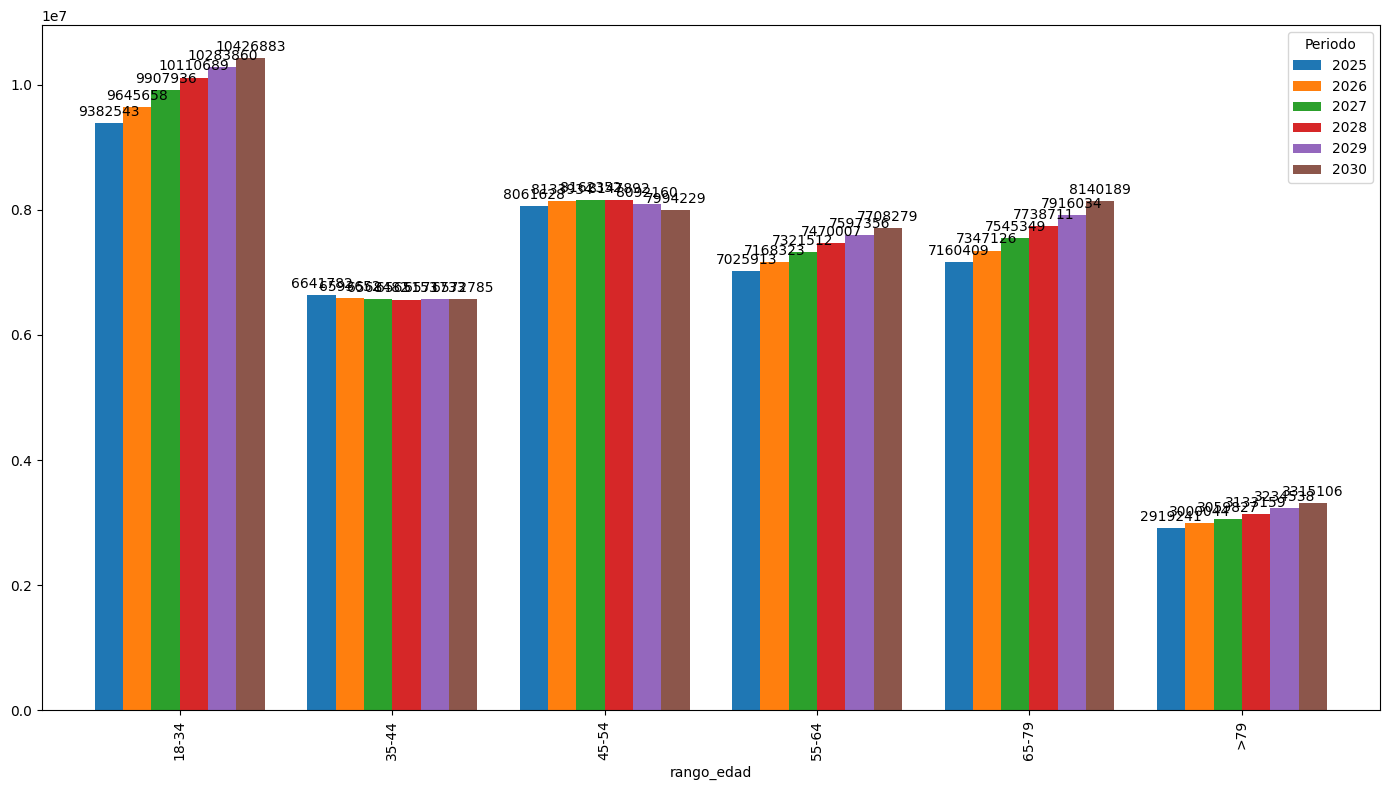

In [35]:
pivot_graf=df2030.pivot_table(index='rango_edad', columns='Periodo', values='Total', aggfunc='sum')

plt.figure(figsize=(14, 8))

# ampliar las barras
ax = pivot_graf.plot.bar(width=0.8, figsize=(14, 8))

# añadir valores encima de las barras 
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)   # padding = la distancia del tag por encima de la barra

plt.tight_layout()
plt.show()


<Axes: xlabel='age_group'>

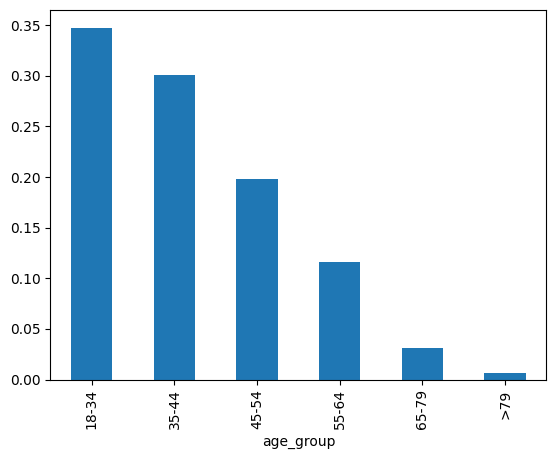

In [36]:
df_banca['age_group'].value_counts(normalize=True).plot.bar()

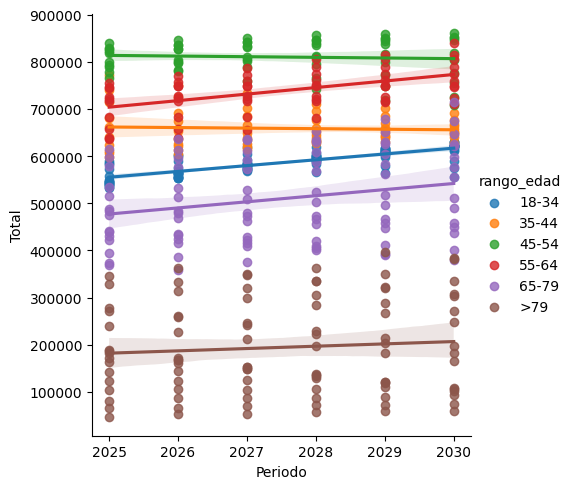

In [37]:
sns.lmplot(data = df2030, x='Periodo', y='Total', hue='rango_edad');

#### Chi2 de bondad ajuste

In [42]:
from scipy import stats

# definir el tamaño total de la muestra (N-total clientes)
N_clientes = 26176

# definir las categorías de edad para la comparación
categorias = ['18-34', '35-44', '45-54', '55-64', '65-79', '>79']

# proporción de clientes proyectada al 2035
P_banco_obs = np.array([0.03, 0.31, 0.30, 0.20, 0.13, 0.03]) 

# proporción de la población proyectada del INE
P_ine_exp = np.array([0.23, 0.15, 0.16, 0.18, 0.20, 0.08]) 

# clacular las frequencias 
# frecuencias observadas
O_obs = P_banco_obs * N_clientes

# frecuencias esperadas
E_exp = P_ine_exp * N_clientes

print("Frecuencias Observadas:", O_obs.round(0))
print("Frecuencias Esperadas:", E_exp.round(0))

Frecuencias Observadas: [ 785. 8115. 7853. 5235. 3403.  785.]
Frecuencias Esperadas: [6020. 3926. 4188. 4712. 5235. 2094.]


In [44]:
# aplicar el chi2 de Bondad de Ajuste
chisq_statistic, p_value = stats.chisquare(f_obs=O_obs, f_exp=E_exp)

print(f"Estadístico Chi-Cuadrado (χ²): {chisq_statistic:.2f}")
print(f"Valor p (p-value): {p_value:.10f}")

Estadístico Chi-Cuadrado (χ²): 13743.76
Valor p (p-value): 0.0000000000


# <span style="color: rgba(230, 0, 126, 1);"> MARCOS </span> #

## <span style="color: rgba(230, 0, 126, 1);"> Proyección poblacional </span> ##

### <span style="color: rgba(230, 0, 126, 1);"> 1.- Importación de librerias para el análisis de datos </span> ###

In [ ]:
# importación de librerias para el análisis de datos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# ignorar warnings para ver salidas mas claras
import warnings
warnings.filterwarnings('ignore')

### <span style="color: rgba(230, 0, 126, 1);"> 2.- Importación del dataset INE </span> ###

In [ ]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df=pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\251118_Proyeccion_Edad_INE.csv",sep=";",encoding="latin-1")
df.describe()
df

,Sexo,Edad,Periodo,Total
0,Hombres,18 años,2035,"267.268,797678"
1,Hombres,18 años,2034,"271.943,940934"
2,Hombres,18 años,2033,"275.580,015178"
3,Hombres,18 años,2032,"271.923,902879"
4,Hombres,18 años,2031,"284.079,391527"
...,...,...,...,...
1711,Mujeres,95 años,2029,"42.441,697299"
1712,Mujeres,95 años,2028,"41.629,112226"
1713,Mujeres,95 años,2027,"38.438,139278"
1714,Mujeres,95 años,2026,"38.342,631189"


### <span style="color: rgba(230, 0, 126, 1);"> 3.- Importación del dataset Desafío 3 </span> ###

In [ ]:
# la r al inicio cambia el sentido de la contrabarra en el path del repositorio local copiada directamente del explorador de windows. sep0";" indica como están separados los campos en el archivo csv"
df_w03=pd.read_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\101125_dataset.csv",sep=";")
df_w03.describe()
df_w03

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,administrative,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,administrative,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,administrative,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26171,26383,59.0,administrative,married,secondary,no,3735,no,no,cellular,18,mar,203,4,121,2,failure,yes,56 - 65
26172,26384,56.0,management,married,tertiary,no,6798,yes,no,cellular,17,nov,250,1,-1,0,unknown,no,56 - 65
26173,26385,40.0,administrative,single,secondary,no,50,no,no,cellular,15,may,837,1,-1,0,unknown,yes,36 - 45
26174,26386,34.0,blue-collar,married,secondary,no,2994,yes,no,cellular,15,may,358,1,176,1,failure,no,26 - 35


### <span style="color: rgba(230, 0, 126, 1);"> 4.- Limpiar dataset EDAD extraído del INE </span> ###
- Eliminar 'Sexo'='Total'
- Convertir a númerico el campo edad -eliminar 'años'-
- Convertir a entero el campo 'Total'. Primero normalizar las comas y los puntos
- Agrupar por rangos las edades, haciéndolos coincidir con los rangos de la encuesta

In [ ]:
# eliminar 'Sexo'=' Total'

# Opción 1: eliminar por índices
#indicesEliminar=df[df['Sexo']=='Total'].index
#indicesEliminar

# eliminar las filas usando el método drop
#df.drop(indicesEliminar, inplace=True)


# Opción 2: crear un nuevo dataframe sin registros que contengan el valor a eliminar
#   crear un nuevo dataframe sin 'Sexo'='True' y así no machaco el original
#   Eliminar filas donde 'C' es True (mantener las que son False)
df_edad=df[df['Sexo']!='Total']
df_edad

,Sexo,Edad,Periodo,Total
0,Hombres,18 años,2035,"267.268,797678"
1,Hombres,18 años,2034,"271.943,940934"
2,Hombres,18 años,2033,"275.580,015178"
3,Hombres,18 años,2032,"271.923,902879"
4,Hombres,18 años,2031,"284.079,391527"
...,...,...,...,...
1711,Mujeres,95 años,2029,"42.441,697299"
1712,Mujeres,95 años,2028,"41.629,112226"
1713,Mujeres,95 años,2027,"38.438,139278"
1714,Mujeres,95 años,2026,"38.342,631189"


In [ ]:
# normalizar la columna Edad extrayendo solo los números del str y convertirla en integro
df_edad['Edad']=df_edad['Edad'].str.extract(r'(\d+)').astype(int)

In [ ]:
# normalizar la columna Total, eliminando el punto de los miles y cambiando el coma de los decimales a punto, convertir la columna en float
df_edad['Total']=(df_edad['Total'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float).round(0).astype(int))

In [ ]:
# agrupar por rangos las edades

# definir los límites de los rangos (bins)
intervalos=[18,35,45,55,65,80,96]

# definir las etiquetas para cada intervalo
etiquetas=['18-34','35-44','45-54','55-64','65-79','>79']

# creamos nueva columna con pd.cut()
df_edad['rango_edad']=pd.cut(df_edad['Edad'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'Edad'
col='rango_edad'
col_ref='Edad'  # columna de referencia
cols=list(df_edad.columns)
cols.insert(cols.index(col_ref)+1,cols.pop(cols.index(col)))
df_edad=df_edad[cols]
df_edad

,Sexo,Edad,rango_edad,Periodo,Total
0,Hombres,18,18-34,2035,267269
1,Hombres,18,18-34,2034,271944
2,Hombres,18,18-34,2033,275580
3,Hombres,18,18-34,2032,271924
4,Hombres,18,18-34,2031,284079
...,...,...,...,...,...
1711,Mujeres,95,>79,2029,42442
1712,Mujeres,95,>79,2028,41629
1713,Mujeres,95,>79,2027,38438
1714,Mujeres,95,>79,2026,38343


In [ ]:
# agrupar por generación

# definir los límites de los rangos (bins)
intervalos=[18,35,55,96]

# definir las etiquetas para cada intervalo
etiquetas=['Z & Millenials','X','Baby Boomers']

# creamos nueva columna con pd.cut()
df_edad['Generacion']=pd.cut(df_edad['Edad'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'rango_edad'
col='Generacion'
col_ref='rango_edad'  # columna de referencia
cols=list(df_edad.columns)
cols.insert(cols.index(col_ref)+1,cols.pop(cols.index(col)))
df_edad=df_edad[cols]
df_edad

,Sexo,Edad,rango_edad,Generacion,Periodo,Total
0,Hombres,18,18-34,Z & Millenials,2035,267269
1,Hombres,18,18-34,Z & Millenials,2034,271944
2,Hombres,18,18-34,Z & Millenials,2033,275580
3,Hombres,18,18-34,Z & Millenials,2032,271924
4,Hombres,18,18-34,Z & Millenials,2031,284079
...,...,...,...,...,...,...
1711,Mujeres,95,>79,Baby Boomers,2029,42442
1712,Mujeres,95,>79,Baby Boomers,2028,41629
1713,Mujeres,95,>79,Baby Boomers,2027,38438
1714,Mujeres,95,>79,Baby Boomers,2026,38343


### <span style="color: rgba(230, 0, 126, 1);"> 5.- construir nueva tabla para análisis final con Power BI </span> ###

- Elaborar un tabla resumen, agrupada por Generaciónes (Z & Millenials - X - Baby Boomers) con los totales, diferencias y % para los años 2025, 203 y 2035.

In [ ]:
# genero un DF para 2025 agrupado por generación
df_edad_2025_generacion = df_edad[df['Periodo']==2025]
df_edad_2025_generacion

df_2025_generacion_group = df_edad_2025_generacion.groupby('Generacion')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2025'})
df_2025_generacion_group

,Generacion,Total_2025
0,Z & Millenials,9382543
1,X,14703414
2,Baby Boomers,17105560


In [ ]:
# genero un DF para 2030 agrupado por generación
df_edad_2030_generacion = df_edad[df['Periodo']==2030]
df_edad_2030_generacion

df_2030_generacion_group = df_edad_2030_generacion.groupby('Generacion')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2030'})
df_2030_generacion_group

,Generacion,Total_2030
0,Z & Millenials,10426884
1,X,14567011
2,Baby Boomers,19163577


In [ ]:
# genero un DF para 2035 agrupado por generación
df_edad_2035_generacion = df_edad[df['Periodo']==2035]
df_edad_2035_generacion

df_2035_generacion_group = df_edad_2035_generacion.groupby('Generacion')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2035'})
df_2035_generacion_group

,Generacion,Total_2035
0,Z & Millenials,10668957
1,X,13930059
2,Baby Boomers,21091216


In [ ]:
# merge de las tres tablas resumidas de 2025, 2030 y 2035 agrupadas por generaciones
merge_25_30=pd.merge(df_2025_generacion_group, df_2030_generacion_group, on="Generacion", how="inner")
df_edad_25_30_35_generacion=pd.merge(merge_25_30, df_2035_generacion_group, on="Generacion", how="inner")
df_edad_25_30_35_generacion

,Generacion,Total_2025,Total_2030,Total_2035
0,Z & Millenials,9382543,10426884,10668957
1,X,14703414,14567011,13930059
2,Baby Boomers,17105560,19163577,21091216


In [ ]:
# Nueva columna: diferencia entre 2025 y 2035
df_edad_25_30_35_generacion["diferencia_25_35"]=df_edad_25_30_35_generacion["Total_2035"]-df_edad_25_30_35_generacion["Total_2025"]

# Nueva columna: % de cambio (2035 vs 2025)
df_edad_25_30_35_generacion["%_cambio_25_35"]=(df_edad_25_30_35_generacion["diferencia_25_35"]/df_edad_25_30_35_generacion["Total_2025"])*100
df_edad_25_30_35_generacion=df_edad_25_30_35_generacion.round(2)

In [ ]:
# Nueva columna: diferencia entre 2025 y 2030
df_edad_25_30_35_generacion["diferencia_25_30"]=df_edad_25_30_35_generacion["Total_2030"]-df_edad_25_30_35_generacion["Total_2025"]

# Nueva columna: % de cambio (2025 vs 2030)
df_edad_25_30_35_generacion["%_cambio_25_30"]=(df_edad_25_30_35_generacion["diferencia_25_30"]/df_edad_25_30_35_generacion["Total_2025"])*100
df_edad_25_30_35_generacion=df_edad_25_30_35_generacion.round(2)

In [ ]:
# Nueva columna: diferencia entre 2030 y 2035
df_edad_25_30_35_generacion["diferencia_30_35"]=df_edad_25_30_35_generacion["Total_2035"]-df_edad_25_30_35_generacion["Total_2030"]

# Nueva columna: % de cambio (2030 vs 2035)
df_edad_25_30_35_generacion["%_cambio_30_35"]=(df_edad_25_30_35_generacion["diferencia_30_35"]/df_edad_25_30_35_generacion["Total_2030"])*100
df_edad_25_30_35_generacion=df_edad_25_30_35_generacion.round(2)

In [ ]:
df_edad_25_30_35_generacion

,Generacion,Total_2025,Total_2030,Total_2035,diferencia_25_35,%_cambio_25_35,diferencia_25_30,%_cambio_25_30,diferencia_30_35,%_cambio_30_35
0,Z & Millenials,9382543,10426884,10668957,1286414,13.71,1044341,11.13,242073,2.32
1,X,14703414,14567011,13930059,-773355,-5.26,-136403,-0.93,-636952,-4.37
2,Baby Boomers,17105560,19163577,21091216,3985656,23.30,2058017,12.03,1927639,10.06


- Elaborar un tabla resumen, agrupada por los Rangos de Edad de las encuestas, con los totales, diferencias y % para los años 2025, 203 y 2035.

In [ ]:
# genero un DF para 2025 agrupado por rango de edades
df_edad_2025_rango_edad = df_edad[df['Periodo']==2025]
df_edad_2025_rango_edad

df_edad_2025_rango_edad_group = df_edad_2025_rango_edad.groupby('rango_edad')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2025'})
df_edad_2025_rango_edad_group


,rango_edad,Total_2025
0,18-34,9382543
1,35-44,6641783
2,45-54,8061631
3,55-64,7025913
4,65-79,7160407
5,>79,2919240


In [ ]:
# genero un DF para 2030 agrupado por rango de edades
df_edad_2030_rango_edad = df_edad[df['Periodo']==2030]
df_edad_2030_rango_edad

df_edad_2030_rango_edad_group = df_edad_2030_rango_edad.groupby('rango_edad')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2030'})
df_edad_2030_rango_edad_group


,rango_edad,Total_2030
0,18-34,10426884
1,35-44,6572783
2,45-54,7994228
3,55-64,7708281
4,65-79,8140189
5,>79,3315107


In [ ]:
# genero un DF para 2035 agrupado por rango de edades
df_edad_2035_rango_edad = df_edad[df['Periodo']==2035]
df_edad_2035_rango_edad

df_edad_2035_rango_edad_group = df_edad_2035_rango_edad.groupby('rango_edad')['Total'].sum().reset_index().rename(columns={'Total': 'Total_2035'})
df_edad_2035_rango_edad_group


,rango_edad,Total_2035
0,18-34,10668957
1,35-44,6644628
2,45-54,7285431
3,55-64,8182160
4,65-79,9194954
5,>79,3714102


In [ ]:
# merge de las tres tablas resumidas de 2025, 2030 y 2035 agrupadas por rango de edad
merge_25_30_rango_edad=pd.merge(df_edad_2025_rango_edad_group, df_edad_2030_rango_edad_group, on="rango_edad", how="inner")
df_edad_25_30_35_rango_edad=pd.merge(merge_25_30_rango_edad, df_edad_2035_rango_edad_group, on="rango_edad", how="inner")
df_edad_25_30_35_rango_edad


,rango_edad,Total_2025,Total_2030,Total_2035
0,18-34,9382543,10426884,10668957
1,35-44,6641783,6572783,6644628
2,45-54,8061631,7994228,7285431
3,55-64,7025913,7708281,8182160
4,65-79,7160407,8140189,9194954
5,>79,2919240,3315107,3714102


In [ ]:
# Nueva columna: diferencia entre 2025 y 2035
df_edad_25_30_35_rango_edad["diferencia_25_35"]=df_edad_25_30_35_rango_edad["Total_2035"]-df_edad_25_30_35_rango_edad["Total_2025"]

# Nueva columna: % de cambio (2035 vs 2025)
df_edad_25_30_35_rango_edad["%_cambio_25_35"]=(df_edad_25_30_35_rango_edad["diferencia_25_35"]/df_edad_25_30_35_rango_edad["Total_2025"])*100
df_edad_25_30_35_rango_edad=df_edad_25_30_35_rango_edad.round(2)

In [ ]:
# Nueva columna: diferencia entre 2025 y 2030
df_edad_25_30_35_rango_edad["diferencia_25_30"]=df_edad_25_30_35_rango_edad["Total_2030"]-df_edad_25_30_35_rango_edad["Total_2025"]

# Nueva columna: % de cambio (2025 vs 2030)
df_edad_25_30_35_rango_edad["%_cambio_25_30"]=(df_edad_25_30_35_rango_edad["diferencia_25_30"]/df_edad_25_30_35_rango_edad["Total_2025"])*100
df_edad_25_30_35_rango_edad=df_edad_25_30_35_rango_edad.round(2)

In [ ]:
# Nueva columna: diferencia entre 2030 y 2035
df_edad_25_30_35_rango_edad["diferencia_30_35"]=df_edad_25_30_35_rango_edad["Total_2035"]-df_edad_25_30_35_rango_edad["Total_2030"]

# Nueva columna: % de cambio (2030 vs 2035)
df_edad_25_30_35_rango_edad["%_cambio_30_35"]=(df_edad_25_30_35_rango_edad["diferencia_30_35"]/df_edad_25_30_35_rango_edad["Total_2030"])*100
df_edad_25_30_35_rango_edad=df_edad_25_30_35_rango_edad.round(2)

In [ ]:
df_edad_25_30_35_rango_edad

,rango_edad,Total_2025,Total_2030,Total_2035,diferencia_25_35,%_cambio_25_35,diferencia_25_30,%_cambio_25_30,diferencia_30_35,%_cambio_30_35
0,18-34,9382543,10426884,10668957,1286414,13.71,1044341,11.13,242073,2.32
1,35-44,6641783,6572783,6644628,2845,0.04,-69000,-1.04,71845,1.09
2,45-54,8061631,7994228,7285431,-776200,-9.63,-67403,-0.84,-708797,-8.87
3,55-64,7025913,7708281,8182160,1156247,16.46,682368,9.71,473879,6.15
4,65-79,7160407,8140189,9194954,2034547,28.41,979782,13.68,1054765,12.96
5,>79,2919240,3315107,3714102,794862,27.23,395867,13.56,398995,12.04


### <span style="color: rgba(230, 0, 126, 1);"> 6.- Exploración dataset limpio W03 </span> ###

In [ ]:
# agrupar por rangos las edades

# definir los límites de los rangos (bins)
intervalos=[18,35,45,55,65,80,96]

# definir las etiquetas para cada intervalo
etiquetas=['18-34','35-44','45-54','55-64','65-79','>79']

# creamos nueva columna con pd.cut()
df_w03['rango_edad']=pd.cut(df_w03['age'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'Edad'
col='rango_edad'
col_ref='age'  # columna de referencia
cols=list(df_w03.columns)
cols.insert(cols.index(col_ref)+1,cols.pop(cols.index(col)))
df_w03=df_w03[cols]
df_w03

,id,age,rango_edad,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,55-64,administrative,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,55-64,administrative,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,35-44,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,55-64,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,45-54,administrative,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26171,26383,59.0,55-64,administrative,married,secondary,no,3735,no,no,cellular,18,mar,203,4,121,2,failure,yes,56 - 65
26172,26384,56.0,55-64,management,married,tertiary,no,6798,yes,no,cellular,17,nov,250,1,-1,0,unknown,no,56 - 65
26173,26385,40.0,35-44,administrative,single,secondary,no,50,no,no,cellular,15,may,837,1,-1,0,unknown,yes,36 - 45
26174,26386,34.0,18-34,blue-collar,married,secondary,no,2994,yes,no,cellular,15,may,358,1,176,1,failure,no,26 - 35


In [ ]:
# agrupar por generación

# definir los límites de los rangos (bins)
intervalos=[18,35,55,96]

# definir las etiquetas para cada intervalo
etiquetas=['Z & Millenials','X','Baby Boomers']

# creamos nueva columna con pd.cut()
df_w03['Generacion']=pd.cut(df_w03['age'],bins=intervalos,labels=etiquetas,right=False)

# mover la nueva columna junto 'rango_edad'
col='Generacion'
col_ref='rango_edad'  # columna de referencia
cols=list(df_w03.columns)
cols.insert(cols.index(col_ref)+1,cols.pop(cols.index(col)))
df_w03=df_w03[cols]
df_w03

,id,age,rango_edad,Generacion,job,marital,education,default,balance,housing,...,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,age_group
0,1,59.0,55-64,Baby Boomers,administrative,married,secondary,no,2343,yes,...,unknown,5,may,1042,1,-1,0,unknown,yes,56 - 65
1,2,56.0,55-64,Baby Boomers,administrative,married,secondary,no,45,no,...,unknown,5,may,1467,1,-1,0,unknown,yes,56 - 65
2,3,41.0,35-44,X,technician,married,secondary,no,1270,yes,...,unknown,5,may,1389,1,-1,0,unknown,yes,36 - 45
3,4,55.0,55-64,Baby Boomers,services,married,secondary,no,2476,yes,...,unknown,5,may,579,1,-1,0,unknown,yes,46 - 55
4,5,54.0,45-54,X,administrative,married,tertiary,no,184,no,...,unknown,5,may,673,2,-1,0,unknown,yes,46 - 55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26171,26383,59.0,55-64,Baby Boomers,administrative,married,secondary,no,3735,no,...,cellular,18,mar,203,4,121,2,failure,yes,56 - 65
26172,26384,56.0,55-64,Baby Boomers,management,married,tertiary,no,6798,yes,...,cellular,17,nov,250,1,-1,0,unknown,no,56 - 65
26173,26385,40.0,35-44,X,administrative,single,secondary,no,50,no,...,cellular,15,may,837,1,-1,0,unknown,yes,36 - 45
26174,26386,34.0,18-34,Z & Millenials,blue-collar,married,secondary,no,2994,yes,...,cellular,15,may,358,1,176,1,failure,no,26 - 35


### <span style="color: rgba(230, 0, 126, 1);"> 7.- Exportación a csv </span> ###

In [ ]:
df_edad.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\251120_INE_limpio.csv",sep=";",index=False)
df_edad_25_30_35_generacion.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\251120_INE_limpio_generaciones.csv",sep=";",index=False)
df_edad_25_30_35_rango_edad.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\251120_INE_limpio_rango_edad.csv",sep=";",index=False)
df_w03.to_csv(r"C:\MNG\03_IT Academy\04_Simulador empresarial (SE)\251117_MNG_W04\251120_W03_limpio.csv",sep=";",index=False)